In [1]:
import sys
from pathlib import Path
import json
import pickle
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kmodes.kmodes import KModes
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from src.constants import (
    TARGET_COL,
    MULTILABEL_COLS,
    CATEGORICAL_COLS,
    FEATURE_COLS,
    CLASS_LABELS,
    RANDOM_STATE,
    PROCESSED_DATA_PATH,
    ARTIFACTS_PATH
)
from src.preprocessing import load_processed_dataset, validate_processed_dataset
from src.visualisations import plot_cluster_distribution
from src.encoders import (
    fit_mlb_encoder,
    fit_ohe_encoder,
    build_mlb_cat_matrix,
    build_mlb_ohe_matrix,
    save_encoders,
)

In [2]:
df= load_processed_dataset(PROCESSED_DATA_PATH)
validate_processed_dataset(df)

df = df.copy().reset_index(drop=True)

X_cluster_raw = df[FEATURE_COLS].astype(str).copy().reset_index(drop=True)
y_true = df[TARGET_COL].astype(str).reset_index(drop=True).astype(str)

print(f"Dataset shape: {df.shape}")
print(f"Raw cluster matrix shape: {X_cluster_raw.shape}")
print(f"Mutli-valued columns: {MULTILABEL_COLS}")
print(f"Single-valued categorical columns: {CATEGORICAL_COLS}")

print(f"\nFeature value counts (top 5 per column):")
for col in FEATURE_COLS:
    print(f"\n{col}: {X_cluster_raw[col].nunique()} unique values")
    print(X_cluster_raw[col].value_counts().head(5).to_string())

print("\nTarget distribution (for cluster interpretation only):")
print(y_true.value_counts())

assert X_cluster_raw.isnull().sum().sum() == 0
print("\nNo nulls in cluster matrix")

Dataset shape: (9250, 9)
Raw cluster matrix shape: (9250, 6)
Mutli-valued columns: ['data_subject_type', 'data_type']
Single-valued categorical columns: ['incident_category', 'incident_type', 'no_data_subjects_affected', 'time_taken_to_report']

Feature value counts (top 5 per column):

data_subject_type: 94 unique values
data_subject_type
Patients               4857
Unknown                1410
Employees               819
Children, Patients      328
Employees, Patients     300

data_type: 246 unique values
data_type
Basic personal identifiers, Health data                    4046
Unknown                                                    1562
Basic personal identifiers                                 1536
Health data                                                 897
Basic personal identifiers, Economic and financial data     137

incident_category: 2 unique values
incident_category
Non Cyber    8309
Cyber         941

incident_type: 21 unique values
incident_type
Other non-cyber incid

In [3]:
k_range = range(2, 11)
KMODES_INIT = "Huang"
N_INIT_GRID = 20
N_INIT_FINAL = 50

In [4]:
def safe_hamming_silhouette(X_silhouette, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) <= 1 or len(unique_labels) >= len(labels):
        return np.nan
    return silhouette_score(X_silhouette, labels, metric="hamming")

def make_silhouette_matrix(df: pd.DataFrame) -> np.ndarray:
    return pd.get_dummies(df.astype(str)).astype(int).values

def run_kmodes_grid(df: pd.DataFrame, X_silhouette: np.ndarray, k_range: range, model_label: str) -> dict:
    costs = []
    silhouettes = []
    
    print(f"{model_label}: K search")
    for k in k_range:
        kmodes = KModes(
            n_clusters=k,
            init=KMODES_INIT,
            n_init=N_INIT_GRID,
            random_state=RANDOM_STATE,
            verbose=0
        )
        labels = kmodes.fit_predict(df.astype(str))
        silhouette = safe_hamming_silhouette(X_silhouette, labels)
        
        costs.append(kmodes.cost_)
        silhouettes.append(silhouette)
        print(f"k={k}: cost={kmodes.cost_}, silhouette={silhouette:.4f}")
        
    return costs, silhouettes

def plot_kmodes_grid(costs, silhouettes, title, k_range):
    fig, ax_cost = plt.subplots(figsize=(12, 5))
    
    ax_cost.set_xlabel("Number of Clusters (k)", fontsize=12)
    ax_cost.set_ylabel("Kmodes Cost", fontsize=12)
    ax_cost.plot(list(k_range), costs, marker="o", color="blue")
    ax_cost.tick_params(axis="y")
    
    ax_silhouette = ax_cost.twinx()
    ax_silhouette.set_ylabel("Silhouette Score", fontsize=12)
    ax_silhouette.plot(list(k_range), silhouettes, marker="s", color="orange")
    ax_silhouette.tick_params(axis="y")
    
    ax_cost.set_title(title, fontsize=14, fontweight="bold")
    ax_cost.legend()
    plt.show()
    
    valid_silhouettes = np.array(silhouettes, dtype=float)
    if np.isfinite(valid_silhouettes).any():
        best_idx = int(np.nanargmax(valid_silhouettes))
        best_k = list(k_range)[best_idx]
        print(f"Best K based on silhouette: {best_k} with silhouette={valid_silhouettes[best_idx]:.4f}")
        return best_k
    
    print("No valid silhouette score could be calculated to determine best K.")
    return None

def fit_final_kmodes(df: pd.DataFrame, k: int, model_label: str):
    print(f"\n{model_label}: Fitting final model with k={k}")
    kmodes = KModes(
        n_clusters=k,
        init=KMODES_INIT,
        n_init=N_INIT_FINAL,
        random_state=RANDOM_STATE,
        verbose=0
    )
    
    labels = kmodes.fit_predict(df.astype(str))
    
    print("\nCluster Sizes:")
    sizes = pd.Series(labels).value_counts().sort_index()
    for cluster_id, count in sizes.items():
        print(f"\tCluster {cluster_id}: {count} breaches ({count / len(labels) * 100:.1f}%)")
    print(f"\nFinal cost: {kmodes.cost_:.0f}")
    
    return kmodes, labels

def evaluate_cluster_alignment(model_label: str, labels, y_true: pd.Series):
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    
    print(f"\n{model_label} Cluster Alignment with true Labels:")
    print(f"Adjusted Rand Index: {ari:.4f}")
    print(f"Normalized Mutual Information: {nmi:.4f}")
    
    rng = np.random.default_rng(RANDOM_STATE)
    shuffled = rng.permutation(labels)
    ari_shuffled = adjusted_rand_score(y_true, shuffled)
    nmi_shuffled = normalized_mutual_info_score(y_true, shuffled)
    
    print(f"Random shuffle baseline: ARI={ari_shuffled:.4f}, NMI={nmi_shuffled:.4f}")
    
    return ari, nmi, ari_shuffled, nmi_shuffled

def cluster_summary(model_name, labels, final_k, ari, nmi, silhouette_at_k, cost, n_features):
    sizes = pd.Series(labels).value_counts().sort_index()
    summary = {
        "model": model_name,
        "n_clusters": int(final_k),
        "n_features": int(n_features),
        "cost": float(cost),
        "silhouette_at_k": float(silhouette_at_k) if pd.notna(silhouette_at_k) else np.nan,
        "ari": float(ari),
        "nmi": float(nmi),
        "min_cluster_size": int(sizes.min()),
        "max_cluster_size": int(sizes.max()),
        "smallest_cluster_percent": float(sizes.min() / len(labels) * 100),
        "largest_cluster_percent": float(sizes.max() / len(labels) * 100)
    }
    return summary

def show_centroids(kmodes_model, labels, feature_names, final_k, title):
    centroids = pd.DataFrame(kmodes_model.cluster_centroids_, columns=feature_names)
    centroids.index.name = "Cluster"
    
    print(f"\n{title}")
    print(centroids.to_string())
    
    centroids_with_size = centroids.copy()
    centroids_with_size.insert(0, "Size", [int((labels == c).sum()) for c in range(final_k)])
    centroids_with_size.insert(1, "Size (%)", [f"{(labels == c).mean() * 100:.1f}%" for c in range(final_k)])
    
    print(f"\n Cluster Centroids with sizes:\n{centroids_with_size.to_string()}\n")
    return centroids, centroids_with_size
    
def analysis_df(labels):
    df_analysis = df[FEATURE_COLS + [TARGET_COL]].copy().reset_index(drop=True)
    df_analysis["cluster"] = labels
    return df_analysis

def print_cluster_crosstabs(df_analysis, model_label):
    print(f"{model_label}: Cluster vs Decision Taken (Counts)")
    counts = pd.crosstab(df_analysis["cluster"], df_analysis[TARGET_COL], margins=True)
    print(counts.to_string())
    
    print(f"\nRow proportions (within each cluster):")
    row_props = pd.crosstab(df_analysis["cluster"], df_analysis[TARGET_COL], normalize="index").round(4)
    print(row_props.to_string())
    
    print(f"\nColumn proportions (within each decision):")
    col_props = pd.crosstab(df_analysis["cluster"], df_analysis[TARGET_COL], normalize="columns").round(4)
    print(col_props.to_string())
    
    return counts, row_props, col_props

def print_cluster_dominance(df_analysis, final_k, model_label):
    print(f"{model_label}: Per-cluster feature dominance")
    for cluster_id in range(final_k):
        cluster_rows = df_analysis[df_analysis["cluster"] == cluster_id]
        print(f"\nCluster {cluster_id} ({len(cluster_rows)} breaches, {len(cluster_rows) / len(df_analysis) * 100:.1f}%)")

        for col in FEATURE_COLS:
            top = cluster_rows[col].value_counts(normalize=True).head(1)
            if len(top) > 0:
                value, prop = top.index[0], top.iloc[0]
                print(f"\t{col}: {value} ({prop:.1%} of cluster)")
        
        decision_distribution = cluster_rows[TARGET_COL].value_counts(normalize=True)
        print(f"\tDecision Taken distribution within cluster:")
        for label in CLASS_LABELS:
            prop = decision_distribution.get(label, 0.0)
            print(f"\t{label}: {prop:.1%}")
            
def validate_kmodes_outputs(df, labels, final_k, ari):
    assert len(labels) == len(df), "Label/ row count mismatch"
    print(f"Every row assigned a cluster label {len(labels)} labels")
    
    assert len(np.unique(labels)) == final_k, f"Expected {final_k} unique clusters, got {len(np.unique(labels))}"
    print(f"Correct number of unique clusters: {final_k}")
    
    _, counts = np.unique(labels, return_counts=True)
    assert (counts > 0).all(), "Empty clusters found"
    print("No empty clusters found")
    
    assert  -0.5 <= ari <= 1, f"ARI is very negative: {ari}"
    print(f"ARI within expected range: {ari:.4f}")

In [5]:
# Model 1: Baseline with native categorical features
X_cluster_cat = df[FEATURE_COLS].astype(str).copy().reset_index(drop=True)
X_ohe_cat = make_silhouette_matrix(X_cluster_cat)

mlb_encoders = fit_mlb_encoder(df, MULTILABEL_COLS)
ohe_encoder = fit_ohe_encoder(df, CATEGORICAL_COLS)

# Model 2: Native Cat + MLB
X_cluster_mlb_cat, cat_feature_indicies = build_mlb_cat_matrix(
    df, 
    mlb_encoders=mlb_encoders,
    multilabel_cols=MULTILABEL_COLS,
    categorical_cols=CATEGORICAL_COLS
)
X_cluster_mlb_cat = X_cluster_mlb_cat.astype(str).reset_index(drop=True)
X_ohe_mlb = make_silhouette_matrix(X_cluster_mlb_cat)

# Model 3: MultiLabelBinarizer + OneHotEncoder (full binary matrix)
X_cluster_mlb_ohe = build_mlb_ohe_matrix(
    df,
    mlb_encoders=mlb_encoders,
    ohe_encoder=ohe_encoder,
    multilabel_cols=MULTILABEL_COLS,
    categorical_cols=CATEGORICAL_COLS
).reset_index(drop=True)
X_cluster_encoded = X_cluster_mlb_ohe.astype(int).astype(str)
X_ohe_encoded = X_cluster_mlb_ohe.astype(int).values

print("Model 1: native categorical shape:", X_cluster_cat.shape)
print("Model 2: native Cat + MLB shape:", X_cluster_mlb_cat.shape)
print("Model 3: MLB + OHE shape:", X_cluster_encoded.shape)

print("Model 2:")
print(f"Categorical columns in Model 2: {len(cat_feature_indicies)}")
print(f"MLB columns in Model 2: {X_cluster_mlb_cat.shape[1] - len(cat_feature_indicies)}")

print("Model 3:")
print(f"OHE columns in Model 3: {len(ohe_encoder.get_feature_names_out(CATEGORICAL_COLS))}")
print(f"MLB columns in Model 3: {X_cluster_mlb_ohe.shape[1] - len(ohe_encoder.get_feature_names_out(CATEGORICAL_COLS))}")

for col, encoder in mlb_encoders.items():
    print(f"{col}: {len(encoder.classes_)} MLB classes")

Model 1: native categorical shape: (9250, 6)
Model 2: native Cat + MLB shape: (9250, 29)
Model 3: MLB + OHE shape: (9250, 59)
Model 2:
Categorical columns in Model 2: 4
MLB columns in Model 2: 25
Model 3:
OHE columns in Model 3: 34
MLB columns in Model 3: 25
data_subject_type: 9 MLB classes
data_type: 16 MLB classes


In [6]:
# Model 1: Native Categorical Kmodes
cat_kmodes_costs, cat_kmodes_silhouettes = run_kmodes_grid(
    df=X_cluster_cat,
    X_silhouette=X_ohe_cat,
    k_range=k_range,
    model_label="Model 1: Native Categorical Kmodes"
)

Model 1: Native Categorical Kmodes: K search
k=2: cost=24395.0, silhouette=0.1020
k=3: cost=22134.0, silhouette=0.1028
k=4: cost=20721.0, silhouette=0.1201
k=5: cost=20250.0, silhouette=0.1085
k=6: cost=19619.0, silhouette=0.1061
k=7: cost=18759.0, silhouette=0.0809
k=8: cost=18612.0, silhouette=0.0414
k=9: cost=17812.0, silhouette=0.1026
k=10: cost=17529.0, silhouette=0.0574


C:\Users\elsad\AppData\Local\Temp\ipykernel_4300\3817186157.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_cost.legend()


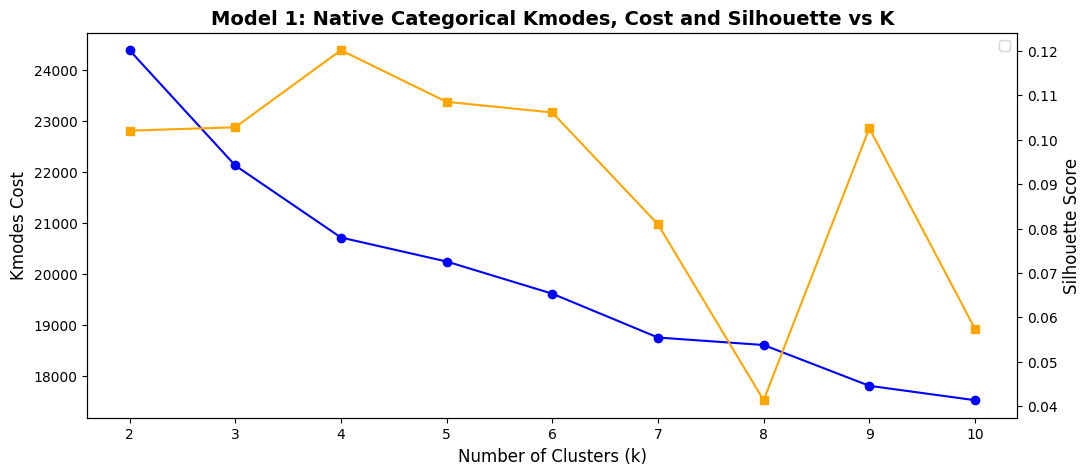

Best K based on silhouette: 4 with silhouette=0.1201


In [7]:
best_silhouette_k_cat = plot_kmodes_grid(
    cat_kmodes_costs,
    cat_kmodes_silhouettes,
    title="Model 1: Native Categorical Kmodes, Cost and Silhouette vs K",
    k_range=k_range
)

In [8]:
final_k_cat = best_silhouette_k_cat

kmodes_cat_final, kmodes_cat_labels = fit_final_kmodes(
    df=X_cluster_cat,
    k=final_k_cat,
    model_label="Model 1: Native Categorical Kmodes"
)


Model 1: Native Categorical Kmodes: Fitting final model with k=4

Cluster Sizes:
	Cluster 0: 3960 breaches (42.8%)
	Cluster 1: 2683 breaches (29.0%)
	Cluster 2: 1718 breaches (18.6%)
	Cluster 3: 889 breaches (9.6%)

Final cost: 20711


In [9]:
centroids_cat, centroids_cat_with_size = show_centroids(
    kmodes_model=kmodes_cat_final,
    labels=kmodes_cat_labels,
    feature_names=FEATURE_COLS,
    final_k=final_k_cat,
    title="Model 1: Native Categorical Kmodes Cluster Centroids"
)


Model 1: Native Categorical Kmodes Cluster Centroids
        data_subject_type                                data_type incident_category                        incident_type no_data_subjects_affected  time_taken_to_report
Cluster                                                                                                                                                                  
0                Patients               Basic personal identifiers         Non Cyber             Other non-cyber incident                    1 to 9  24 hours to 72 hours
1                Patients  Basic personal identifiers, Health data         Non Cyber                  Unauthorised access                    1 to 9      More than 1 week
2                Patients  Basic personal identifiers, Health data         Non Cyber  Data emailed to incorrect recipient                    1 to 9    Less than 24 hours
3                 Unknown                                  Unknown         Non Cyber            


Model 1: Native Categorical Kmodes Cluster Alignment with true Labels:
Adjusted Rand Index: 0.0200
Normalized Mutual Information: 0.0295
Random shuffle baseline: ARI=-0.0013, NMI=0.0010
Model 1: Native Categorical Kmodes: Cluster vs Decision Taken (Counts)
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action   All
cluster                                                                              
0                                3378                    182                400  3960
1                                2108                    301                274  2683
2                                1614                     28                 76  1718
3                                 570                     87                232   889
All                              7670                    598                982  9250

Row proportions (within each cluster):
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action
cluster             

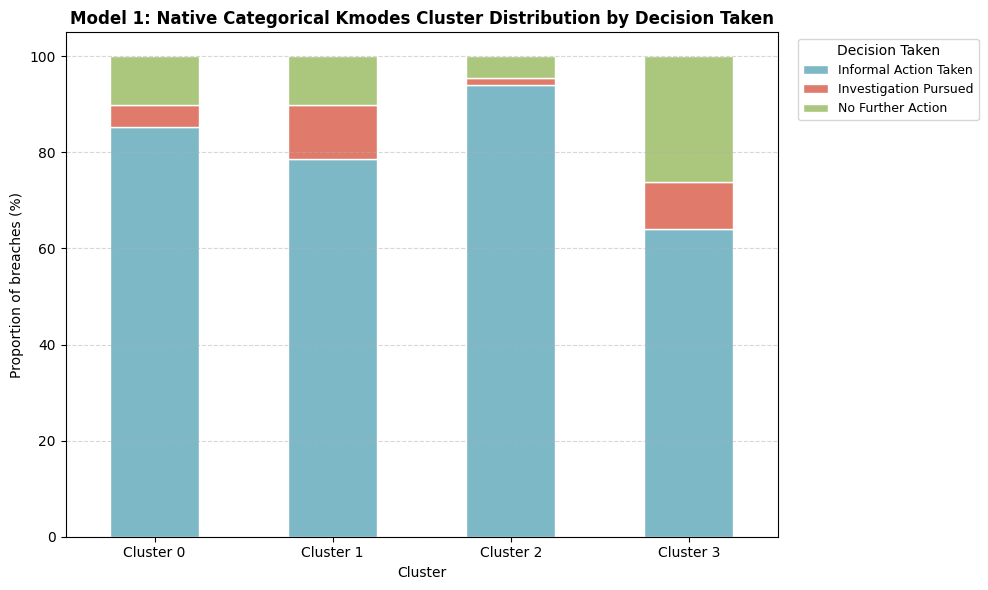

Model 1: Native Categorical Kmodes: Per-cluster feature dominance

Cluster 0 (3960 breaches, 42.8%)
	data_subject_type: Patients (52.6% of cluster)
	data_type: Basic personal identifiers (34.2% of cluster)
	incident_category: Non Cyber (90.0% of cluster)
	incident_type: Other non-cyber incident (29.5% of cluster)
	no_data_subjects_affected: 1 to 9 (66.3% of cluster)
	time_taken_to_report: 24 hours to 72 hours (61.7% of cluster)
	Decision Taken distribution within cluster:
	Informal Action Taken: 85.3%
	Investigation Pursued: 4.6%
	No Further Action: 10.1%

Cluster 1 (2683 breaches, 29.0%)
	data_subject_type: Patients (61.3% of cluster)
	data_type: Basic personal identifiers, Health data (70.1% of cluster)
	incident_category: Non Cyber (92.1% of cluster)
	incident_type: Unauthorised access (43.0% of cluster)
	no_data_subjects_affected: 1 to 9 (68.7% of cluster)
	time_taken_to_report: More than 1 week (59.3% of cluster)
	Decision Taken distribution within cluster:
	Informal Action Taken:

In [10]:
ari_cat, nmi_cat, ari_cat_shuffled, nmi_cat_shuffled = evaluate_cluster_alignment(
    model_label="Model 1: Native Categorical Kmodes",
    labels=kmodes_cat_labels,
    y_true=y_true
)

df_analysis_cat = analysis_df(kmodes_cat_labels)
counts_cat, row_props_cat, col_props_cat = print_cluster_crosstabs(df_analysis_cat, "Model 1: Native Categorical Kmodes")

plot_cluster_distribution(
    cluster_labels=kmodes_cat_labels,
    decision_labels=df_analysis_cat[TARGET_COL],
    class_labels=CLASS_LABELS,
    title="Model 1: Native Categorical Kmodes Cluster Distribution by Decision Taken"
)

print_cluster_dominance(df_analysis_cat, final_k_cat, "Model 1: Native Categorical Kmodes")

In [11]:
print("\nModel 1 Tests:")
validate_kmodes_outputs(
    df=X_cluster_cat,
    labels=kmodes_cat_labels,
    final_k=final_k_cat,
    ari=ari_cat
)


Model 1 Tests:
Every row assigned a cluster label 9250 labels
Correct number of unique clusters: 4
No empty clusters found
ARI within expected range: 0.0200


In [12]:
# Model 2: Native Cat + MLB
mlb_kmodes_costs, mlb_kmodes_silhouettes = run_kmodes_grid(
    df=X_cluster_mlb_cat,
    X_silhouette=X_ohe_mlb,
    k_range=k_range,
    model_label="Model 2: Native Cat + MLB"
)

Model 2: Native Cat + MLB: K search
k=2: cost=30465.0, silhouette=0.3278
k=3: cost=28094.0, silhouette=0.2610
k=4: cost=26598.0, silhouette=0.1239
k=5: cost=24550.0, silhouette=0.1134
k=6: cost=24354.0, silhouette=0.1090
k=7: cost=23036.0, silhouette=0.1152
k=8: cost=22639.0, silhouette=0.1182
k=9: cost=22081.0, silhouette=0.1246
k=10: cost=21766.0, silhouette=0.1239


C:\Users\elsad\AppData\Local\Temp\ipykernel_4300\3817186157.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_cost.legend()


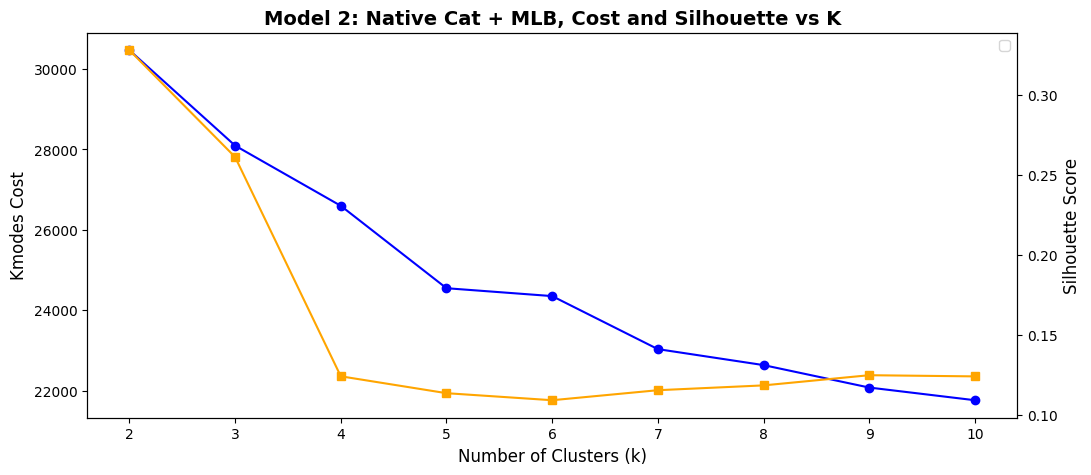

Best K based on silhouette: 2 with silhouette=0.3278


In [13]:
best_silhouette_k_mlb = plot_kmodes_grid(
    mlb_kmodes_costs,
    mlb_kmodes_silhouettes,
    title="Model 2: Native Cat + MLB, Cost and Silhouette vs K",
    k_range=k_range
)

In [ ]:
final_k_mlb = best_silhouette_k_cat

kmodes_mlb_final, kmodes_mlb_labels = fit_final_kmodes(
    df=X_cluster_mlb_cat,
    k=final_k_mlb,
    model_label="Model 2: Native Cat + MLB"
)


Model 2: Native Cat + MLB: Fitting final model with k=4

Cluster Sizes:
	Cluster 0: 2683 breaches (29.0%)
	Cluster 1: 3721 breaches (40.2%)
	Cluster 2: 1801 breaches (19.5%)
	Cluster 3: 1045 breaches (11.3%)

Final cost: 26097


In [15]:
centroids_mlb, centroids_mlb_with_size = show_centroids(
    kmodes_model=kmodes_mlb_final,
    labels=kmodes_mlb_labels,
    feature_names=list(X_cluster_mlb_cat.columns),
    final_k=final_k_mlb,
    title="Model 2: Native Cat + MLB Cluster Centroids"
)


Model 2: Native Cat + MLB Cluster Centroids
        incident_category                        incident_type no_data_subjects_affected  time_taken_to_report data_subject_type__Children data_subject_type__Customers or prospective customers data_subject_type__Employees data_subject_type__Patients data_subject_type__Students data_subject_type__Subscribers data_subject_type__Unknown data_subject_type__Users data_subject_type__Vulnerable adults data_type__Basic personal identifiers data_type__Criminal convictions or offences data_type__Data revealing racial or ethnic origin data_type__Economic and financial data data_type__Gender Reassignment Data data_type__Genetic or biometric data data_type__Health data data_type__Identification data data_type__Location data data_type__Official documents data_type__Political opinions data_type__Religious or philosophical beliefs data_type__Sex life data data_type__Sexual orientation data data_type__Trade union membership data_type__Unknown
Cluster        


Model 2: Native Cat + MLB Cluster Alignment with true Labels:
Adjusted Rand Index: 0.0152
Normalized Mutual Information: 0.0265
Random shuffle baseline: ARI=-0.0044, NMI=0.0006
Model 2: Native Cat + MLB: Cluster vs Decision Taken (Counts)
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action   All
cluster                                                                              
0                                2368                     83                232  2683
1                                3032                    367                322  3721
2                                1601                     58                142  1801
3                                 669                     90                286  1045
All                              7670                    598                982  9250

Row proportions (within each cluster):
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action
cluster                               

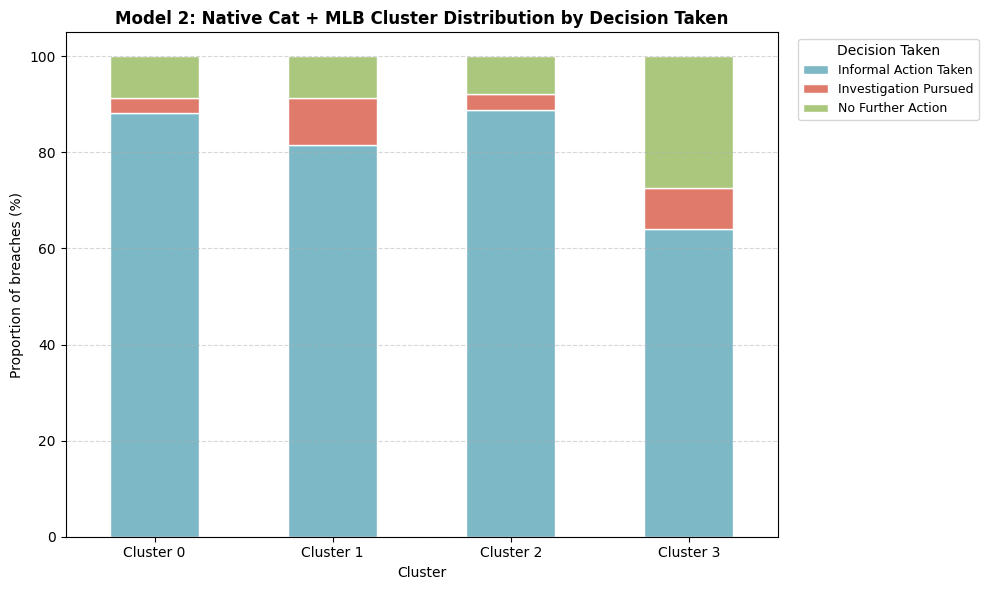

Model 2: Native Cat + MLB: Per-cluster feature dominance

Cluster 0 (2683 breaches, 29.0%)
	data_subject_type: Employees (25.0% of cluster)
	data_type: Basic personal identifiers (45.7% of cluster)
	incident_category: Non Cyber (85.9% of cluster)
	incident_type: Data emailed to incorrect recipient (26.8% of cluster)
	no_data_subjects_affected: 1 to 9 (66.2% of cluster)
	time_taken_to_report: 24 hours to 72 hours (45.1% of cluster)
	Decision Taken distribution within cluster:
	Informal Action Taken: 88.3%
	Investigation Pursued: 3.1%
	No Further Action: 8.6%

Cluster 1 (3721 breaches, 40.2%)
	data_subject_type: Patients (74.7% of cluster)
	data_type: Basic personal identifiers, Health data (68.2% of cluster)
	incident_category: Non Cyber (93.3% of cluster)
	incident_type: Unauthorised access (34.7% of cluster)
	no_data_subjects_affected: 1 to 9 (68.8% of cluster)
	time_taken_to_report: 24 hours to 72 hours (44.8% of cluster)
	Decision Taken distribution within cluster:
	Informal Action 

In [16]:
ari_mlb, nmi_mlb, ari_mlb_shuffled, nmi_mlb_shuffled = evaluate_cluster_alignment(
    model_label="Model 2: Native Cat + MLB",
    labels=kmodes_mlb_labels,
    y_true=y_true
)

df_analysis_mlb = analysis_df(kmodes_mlb_labels)
counts_mlb, row_props_mlb, col_props_mlb = print_cluster_crosstabs(df_analysis_mlb, "Model 2: Native Cat + MLB")

plot_cluster_distribution(
    cluster_labels=kmodes_mlb_labels,
    decision_labels=df_analysis_mlb[TARGET_COL],
    class_labels=CLASS_LABELS,
    title="Model 2: Native Cat + MLB Cluster Distribution by Decision Taken"
)

print_cluster_dominance(df_analysis_mlb, final_k_mlb, "Model 2: Native Cat + MLB")

In [17]:
print("\nModel 2 Tests:")
validate_kmodes_outputs(
    df=X_cluster_mlb_cat,
    labels=kmodes_mlb_labels,
    final_k=final_k_mlb,
    ari=ari_mlb
)


Model 2 Tests:
Every row assigned a cluster label 9250 labels
Correct number of unique clusters: 4
No empty clusters found
ARI within expected range: 0.0152


In [18]:
# Model 3: MLB + OHE (full binary matrix)
encoded_kmodes_costs, encoded_kmodes_silhouettes = run_kmodes_grid(
    df=X_cluster_encoded,
    X_silhouette=X_ohe_encoded,
    k_range=k_range,
    model_label="Model 3: MLB + OHE"
)

Model 3: MLB + OHE: K search
k=2: cost=39711.0, silhouette=0.2823
k=3: cost=36904.0, silhouette=0.1470
k=4: cost=34818.0, silhouette=0.1719
k=5: cost=32186.0, silhouette=0.2248
k=6: cost=30308.0, silhouette=0.2381
k=7: cost=29918.0, silhouette=0.2077
k=8: cost=28932.0, silhouette=0.1895
k=9: cost=27809.0, silhouette=0.2080
k=10: cost=28497.0, silhouette=0.1203


C:\Users\elsad\AppData\Local\Temp\ipykernel_4300\3817186157.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_cost.legend()


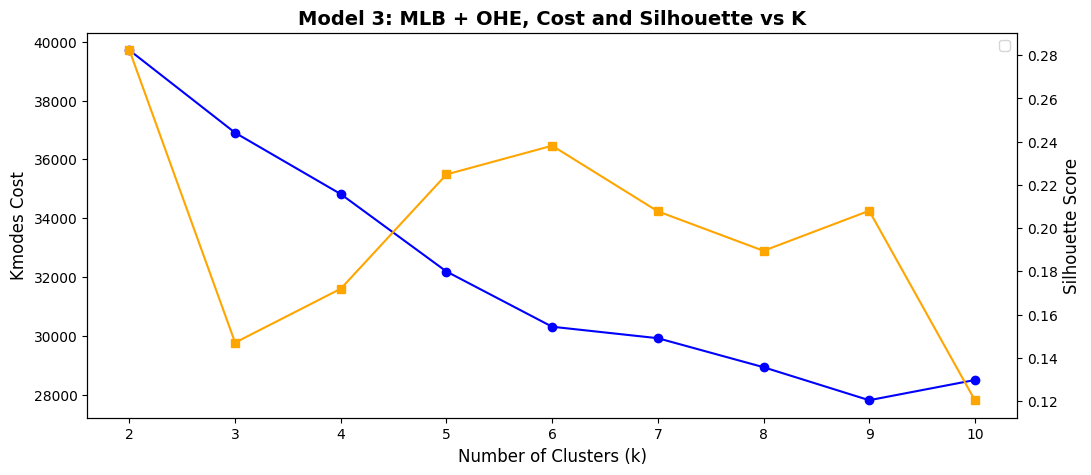

Best K based on silhouette: 2 with silhouette=0.2823


In [19]:
best_silhouette_k_encoded = plot_kmodes_grid(
    encoded_kmodes_costs,
    encoded_kmodes_silhouettes,
    title="Model 3: MLB + OHE, Cost and Silhouette vs K",
    k_range=k_range
)

In [20]:
final_k_encoded = best_silhouette_k_encoded

kmodes_encoded_final, kmodes_encoded_labels = fit_final_kmodes(
    df=X_cluster_encoded,
    k=final_k_encoded,
    model_label="Model 3: MLB + OHE"
)


Model 3: MLB + OHE: Fitting final model with k=2

Cluster Sizes:
	Cluster 0: 2137 breaches (23.1%)
	Cluster 1: 7113 breaches (76.9%)

Final cost: 39299


In [21]:
centroids_encoded, centroids_encoded_with_size = show_centroids(
    kmodes_model=kmodes_encoded_final,
    labels=kmodes_encoded_labels,
    feature_names=list(X_cluster_encoded.columns),
    final_k=final_k_encoded,
    title="Model 3: MLB + OHE Cluster Centroids"
)


Model 3: MLB + OHE Cluster Centroids
        incident_category_Cyber incident_category_Non Cyber incident_type_Alteration of personal data incident_type_Brute Force incident_type_Data emailed to incorrect recipient incident_type_Data of wrong data subject shown in client portal incident_type_Data posted or faxed to incorrect recipient incident_type_Denial of service incident_type_Failure to redact incident_type_Failure to use bcc incident_type_Hardware/software misconfiguration incident_type_Incorrect disposal of hardware incident_type_Incorrect disposal of paperwork incident_type_Loss/theft of device containing personal data incident_type_Loss/theft of paperwork or data left in insecure location incident_type_Malware incident_type_Not Provided incident_type_Other cyber incident incident_type_Other non-cyber incident incident_type_Phishing incident_type_Ransomware incident_type_Unauthorised access incident_type_Verbal disclosure of personal data no_data_subjects_affected_1 to 9 no_dat


Model 3: MLB + OHE Cluster Alignment with true Labels:
Adjusted Rand Index: 0.0844
Normalized Mutual Information: 0.0198
Random shuffle baseline: ARI=-0.0011, NMI=0.0000
Model 3: MLB + OHE: Cluster vs Decision Taken (Counts)
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action   All
cluster                                                                              
0                                1572                    153                412  2137
1                                6098                    445                570  7113
All                              7670                    598                982  9250

Row proportions (within each cluster):
decision_taken  Informal Action Taken  Investigation Pursued  No Further Action
cluster                                                                        
0                              0.7356                 0.0716             0.1928
1                              0.8573                 0.0626    

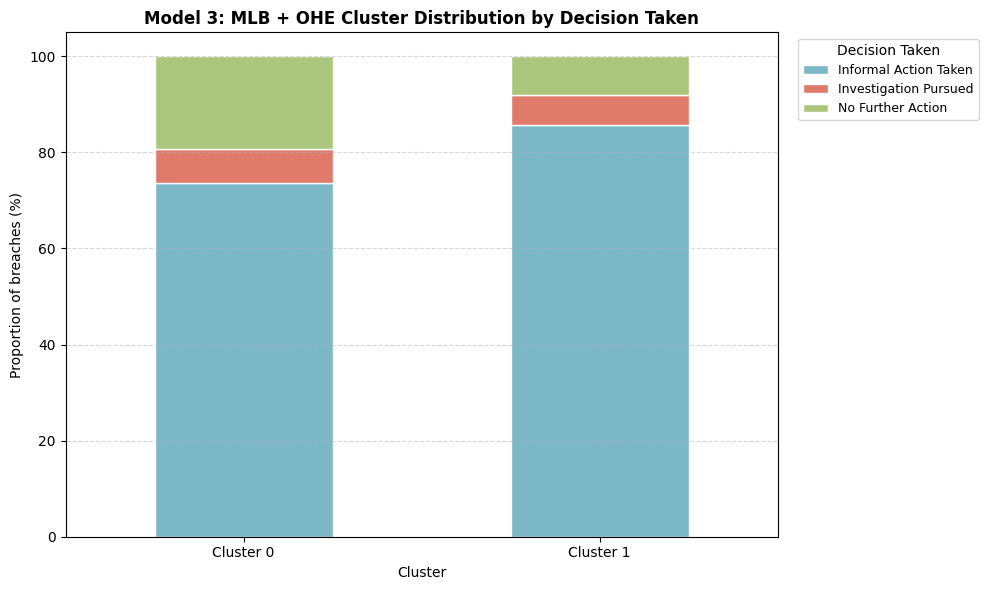

Model 3: MLB + OHE: Per-cluster feature dominance

Cluster 0 (2137 breaches, 23.1%)
	data_subject_type: Unknown (40.2% of cluster)
	data_type: Unknown (73.1% of cluster)
	incident_category: Non Cyber (77.7% of cluster)
	incident_type: Other non-cyber incident (20.6% of cluster)
	no_data_subjects_affected: 1 to 9 (33.1% of cluster)
	time_taken_to_report: Less than 24 hours (33.8% of cluster)
	Decision Taken distribution within cluster:
	Informal Action Taken: 73.6%
	Investigation Pursued: 7.2%
	No Further Action: 19.3%

Cluster 1 (7113 breaches, 76.9%)
	data_subject_type: Patients (61.9% of cluster)
	data_type: Basic personal identifiers, Health data (56.9% of cluster)
	incident_category: Non Cyber (93.5% of cluster)
	incident_type: Other non-cyber incident (18.6% of cluster)
	no_data_subjects_affected: 1 to 9 (73.6% of cluster)
	time_taken_to_report: 24 hours to 72 hours (33.7% of cluster)
	Decision Taken distribution within cluster:
	Informal Action Taken: 85.7%
	Investigation Pursued

In [22]:
ari_encoded, nmi_encoded, ari_encoded_shuffled, nmi_encoded_shuffled = evaluate_cluster_alignment(
    model_label="Model 3: MLB + OHE",
    labels=kmodes_encoded_labels,
    y_true=y_true
)

df_analysis_encoded = analysis_df(kmodes_encoded_labels)
counts_encoded, row_props_encoded, col_props_encoded = print_cluster_crosstabs(df_analysis_encoded, "Model 3: MLB + OHE")

plot_cluster_distribution(
    cluster_labels=kmodes_encoded_labels,
    decision_labels=df_analysis_encoded[TARGET_COL],
    class_labels=CLASS_LABELS,
    title="Model 3: MLB + OHE Cluster Distribution by Decision Taken"
)

print_cluster_dominance(df_analysis_encoded, final_k_encoded, "Model 3: MLB + OHE")

In [23]:
print("\nModel 3 Tests:")
validate_kmodes_outputs(
    df=X_cluster_encoded,
    labels=kmodes_encoded_labels,
    final_k=final_k_encoded,
    ari=ari_encoded
)


Model 3 Tests:
Every row assigned a cluster label 9250 labels
Correct number of unique clusters: 2
No empty clusters found
ARI within expected range: 0.0844


In [24]:
comparison_results = [
    cluster_summary(
        model_name="Model A: Native raw Kmodes",
        labels=kmodes_cat_labels,
        final_k=final_k_cat,
        ari=ari_cat,
        nmi=nmi_cat,
        silhouette_at_k=cat_kmodes_silhouettes[list(k_range).index(final_k_cat)],
        cost=kmodes_cat_final.cost_,
        n_features=X_cluster_cat.shape[1]
    ),
    cluster_summary(
        model_name="Model B: Hybrid native + MLB Kmodes",
        labels=kmodes_mlb_labels,
        final_k=final_k_mlb,
        ari=ari_mlb,
        nmi=nmi_mlb,
        silhouette_at_k=mlb_kmodes_silhouettes[list(k_range).index(final_k_mlb)],
        cost=kmodes_mlb_final.cost_,
        n_features=X_cluster_mlb_cat.shape[1]
    ),
    cluster_summary(
        model_name="Model C: Fully encoded Kmodes",
        labels=kmodes_encoded_labels,
        final_k=final_k_encoded,
        ari=ari_encoded,
        nmi=nmi_encoded,
        silhouette_at_k=encoded_kmodes_silhouettes[list(k_range).index(final_k_encoded)],
        cost=kmodes_encoded_final.cost_,
        n_features=X_cluster_encoded.shape[1]
    ),
]

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,model,n_clusters,n_features,cost,silhouette_at_k,ari,nmi,min_cluster_size,max_cluster_size,smallest_cluster_percent,largest_cluster_percent
0,Model A: Native raw Kmodes,4,6,20711.0,0.120123,0.020024,0.029533,889,3960,9.610811,42.810811
1,Model B: Hybrid native + MLB Kmodes,4,29,26097.0,0.123934,0.015230,0.026452,1045,3721,11.297297,40.227027
2,Model C: Fully encoded Kmodes,2,59,39299.0,0.282312,0.084395,0.019774,2137,7113,23.102703,76.897297


In [25]:
print("Controlled comparison at fixed K:")
print(comparison_df.to_string(index=False))

print("\nRanked by supplementary Hamming silhouette:")
print(comparison_df.sort_values("silhouette_at_k", ascending=False).to_string(index=False))

print("\nRanked by ARI against decision_taken:")
print(comparison_df.sort_values("ari", ascending=False).to_string(index=False))

Controlled comparison at fixed K:
                              model  n_clusters  n_features    cost  silhouette_at_k      ari      nmi  min_cluster_size  max_cluster_size  smallest_cluster_percent  largest_cluster_percent
         Model A: Native raw Kmodes           4           6 20711.0         0.120123 0.020024 0.029533               889              3960                  9.610811                42.810811
Model B: Hybrid native + MLB Kmodes           4          29 26097.0         0.123934 0.015230 0.026452              1045              3721                 11.297297                40.227027
      Model C: Fully encoded Kmodes           2          59 39299.0         0.282312 0.084395 0.019774              2137              7113                 23.102703                76.897297

Ranked by supplementary Hamming silhouette:
                              model  n_clusters  n_features    cost  silhouette_at_k      ari      nmi  min_cluster_size  max_cluster_size  smallest_cluster_perc